# BoldSignal — Batch Brain Score Pipeline
> *Your content, through the brain's eyes.*

Predict human brain engagement for any YouTube video using **Meta's TRIBE v2** fMRI encoding model.
Outputs a **Brain Score (0–100)** across 4 neuroscience dimensions + a second-by-second engagement timeline.

---

## Setup (do this once per runtime)
1. `Runtime → Change runtime type → T4 GPU`
2. Open the **🔑 Secrets** sidebar and add `HF_TOKEN` (your Hugging Face token)
   - Accept the **Llama 3.2** licence gate on HF before running
3. Run **Cell 1** (install) → restart runtime when Colab prompts
4. Run all remaining cells top-to-bottom

## Resuming after a crash / on a new account
- Copy the entire `BoldSignal/` folder to the new account's Drive
- Re-run from Cell 1 — model weights and inference arrays load from Drive, nothing is recomputed

## Drive folder layout
```
MyDrive/BoldSignal/
├── results.json       ← master results (Brain Score for every video)
├── cache/             ← TRIBE v2 weights (~13 GB, reused across runs)
├── preds/             ← inference arrays (.npy + .pkl) per video
└── logs/batch.log     ← timestamped run log
```


In [ ]:
# ── 1. INSTALL ───────────────────────────────────────────────────────────────
!apt-get install -y nodejs > /dev/null 2>&1 && node --version
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"
!uv pip install nilearn "scipy>=1.13.0" yt-dlp
# Restart runtime when Colab prompts, then continue from cell 2

In [2]:
# ── 2. MOUNT DRIVE & SETUP PATHS ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, json, pickle, time, subprocess, logging
from datetime import datetime
import numpy as np

DRIVE_ROOT   = '/content/drive/MyDrive/BoldSignal'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
PREDS_DIR    = f'{DRIVE_ROOT}/preds'
RESULTS_PATH = f'{DRIVE_ROOT}/results.json'
LOG_PATH     = f'{DRIVE_ROOT}/logs/batch.log'

for d in [CACHE_DIR, PREDS_DIR, f'{DRIVE_ROOT}/logs']:
    os.makedirs(d, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(message)s',
    handlers=[logging.FileHandler(LOG_PATH), logging.StreamHandler()]
)
log = logging.getLogger()
print(f'Drive mounted — {DRIVE_ROOT}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted — /content/drive/MyDrive/BoldSignal


In [6]:
# ── 3. IMPORTS ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from scipy.stats import zscore, pearsonr
from nilearn import datasets, surface
import torch

print('CUDA:', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')

CUDA: False | no GPU


In [ ]:
# ── 4. HF AUTHENTICATION ─────────────────────────────────────────────────────
# Add your HuggingFace token to Colab Secrets (🔑 sidebar) as HF_TOKEN
# You must also accept the Llama 3.2 licence at huggingface.co/meta-llama
from google.colab import userdata
from huggingface_hub import login
import os


hf_token = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = hf_token
login(token=hf_token, add_to_git_credential=False)
print('HF auth OK')


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF auth OK


In [3]:
# ── 5. LOAD TRIBE v2 ─────────────────────────────────────────────────────────
# Weights stored in CACHE_DIR on Drive.
# First run: downloads ~13 GB.  All future runs (any account): loads in ~30s.
from tribev2 import TribeModel

if 'CACHE_DIR' not in dir():
    raise RuntimeError('CACHE_DIR not defined — run cell 2 (Mount Drive) first.')

if 'log' not in dir():
    import logging
    log = logging.getLogger()
    if not log.handlers:
        logging.basicConfig(level=logging.INFO, format='%(asctime)s  %(message)s')

log.info('Loading TRIBE v2 from %s', CACHE_DIR)
model = TribeModel.from_pretrained('facebook/tribev2', cache_folder=CACHE_DIR)
log.info('Model ready.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

2026-04-07 03:34:19 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:461: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use 

In [58]:
# ── 6. ATLAS & ROI MAP ───────────────────────────────────────────────────────
destrieux = datasets.fetch_atlas_destrieux_2009()
fsavg5    = datasets.fetch_surf_fsaverage(mesh='fsaverage5')

if 'map_left' in destrieux and 'map_right' in destrieux:
    lh_labels = surface.load_surf_data(destrieux['map_left'])
    rh_labels = surface.load_surf_data(destrieux['map_right'])
else:
    lh_labels = surface.vol_to_surf(
        destrieux['maps'], fsavg5['pial_left'],
        interpolation='nearest_most_frequent').astype(int)
    rh_labels = surface.vol_to_surf(
        destrieux['maps'], fsavg5['pial_right'],
        interpolation='nearest_most_frequent').astype(int)

all_labels  = np.concatenate([lh_labels, rh_labels])
raw         = destrieux['labels']
items       = raw.tolist() if hasattr(raw, 'tolist') else list(raw)
label_names = [v.decode() if isinstance(v, bytes) else str(v) for v in items]

def get_idx(keywords):
    idx = []
    for i, name in enumerate(label_names):
        if any(k.lower() in name.lower() for k in keywords):
            idx.extend(np.where(all_labels == i)[0].tolist())
    return np.array(idx)

ROI = {
    # Default Mode Network — PCC, mPFC, angular gyrus
    'DMN':  get_idx(['cingul', 'front_sup', 'precuneus', 'angular']),

    # Emotional memory circuit
    # Amygdala and hippocampus are subcortical — absent from Destrieux surface atlas.
    # Proxies used:
    #   AMY → temporal pole (G_temporal_pole): anterior temporal cortex directly
    #         adjacent to amygdala; distinct label, no overlap with PHG/HC
    #   PHG → parahippocampal gyrus (G_oc-temp_med-Parahip)
    #   HC  → lingual gyrus (G_oc-temp_med-Lingual): posterior hippocampal projection
    # Note: 'oc-temp_med' is a parent label covering both parahip AND lingual —
    # use the specific child keywords to keep regions separate.
    'AMY':  get_idx(['temporal_pole']),
    'PHG':  get_idx(['parahip']),
    'HC':   get_idx(['oc-temp_med-Lingual']),

    # Social processing
    'pSTS': get_idx(['temp_sup']),
    'FFG':  get_idx(['fusifor']),
    'rTPJ': get_idx(['supramarginal', 'angular']),

    # Sensory salience
    'V1':   get_idx(['cuneus', 'calcarine']),
    'A1':   get_idx(['T_transv', 'temporal_transverse']),
    'INS':  get_idx(['insul', 'Ins']),
}
for k, v in ROI.items():
    print(f'{k:6s}: {len(v):5d} voxels')

# Verify no overlaps in emotional memory circuit
amy_s, phg_s, hc_s = set(ROI['AMY'].tolist()), set(ROI['PHG'].tolist()), set(ROI['HC'].tolist())
print(f'\nOverlap check — AMY∩PHG: {len(amy_s&phg_s)}  AMY∩HC: {len(amy_s&hc_s)}  PHG∩HC: {len(phg_s&hc_s)}  (all should be 0)')

[fetch_atlas_destrieux_2009] Dataset found in /root/nilearn_data/destrieux_2009

/tmp/ipykernel_4575/4195490822.py:2: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index          name
    42 L Medial_wall
   117 R Medial_wall

  destrieux = datasets.fetch_atlas_destrieux_2009()


DMN   :  3579 voxels
AMY   :     0 voxels
PHG   :   292 voxels
HC    :   309 voxels
pSTS  :   653 voxels
FFG   :   223 voxels
rTPJ  :   441 voxels
V1    :  1002 voxels
A1    :   245 voxels
INS   :   838 voxels

Overlap check — AMY∩PHG: 0  AMY∩HC: 0  PHG∩HC: 0  (all should be 0)


In [67]:
# ── 7. HELPERS & SCORING ─────────────────────────────────────────────────────

# ── Calibrated normalisation bounds (pilot: 5 YouTube Shorts, 2026-04-07) ─────
# Derived from DIAG 1 observed ranges ± 20% (5-video pilot, all YouTube Shorts).
# Re-run DIAG 1 with diverse content types to expand these bounds over time.
ATTN_RAW_MIN, ATTN_RAW_MAX =  0.377,  0.486
MEMO_RAW_MIN, MEMO_RAW_MAX = -0.144,  0.153
SOCI_RAW_MIN, SOCI_RAW_MAX = -0.083,  0.607
HOOK_RAW_MIN, HOOK_RAW_MAX =  0.024,  0.082

def normalise(x, in_min=None, in_max=None, out_min=0.0, out_max=1.0):
    if in_min is None: in_min = float(np.min(x))
    if in_max is None: in_max = float(np.max(x))
    x = np.clip(x, in_min, in_max)
    return (x - in_min) / (in_max - in_min + 1e-8) * (out_max - out_min) + out_min

def roi_mean(preds, idx):
    if len(idx) == 0: return np.zeros(preds.shape[0])
    valid = idx[idx < preds.shape[1]]
    return preds[:, valid].mean(axis=1)

def safe_zscore(x):
    if len(x) == 0 or x.std() == 0: return np.zeros(max(len(x), 1))
    return zscore(x)

def get_times(segments, n):
    try:    return np.array([s.start for s in segments])
    except AttributeError:
        try: return np.array([s['onset'] for s in segments])
        except: return np.arange(n, dtype=float)

def detect_narrative_mode(segments, override=None):
    """Return 'narrative' or 'non_narrative'.

    TRIBE v2 segments do not carry transcript data, so auto-detection is not
    yet possible. Always returns 'non_narrative' until Whisper ASR is integrated.
    Pass override='narrative' or override='non_narrative' to force a mode.
    """
    if override is not None:
        return override
    return 'non_narrative'

def construct_narrative_template(n):
    return np.exp(-4 * (np.linspace(0, 1, n) - 0.8)**2)

def score_sustained_attention(preds, mode):
    DMN = roi_mean(preds, ROI['DMN'])
    if len(DMN) == 0: return 0.0
    if mode == 'non_narrative':
        raw = 0.40*(-DMN.mean()) + 0.60*(1-(DMN.std()/(np.ptp(DMN)+1e-8)))
        return float(normalise(raw, ATTN_RAW_MIN, ATTN_RAW_MAX) * 30)
    r = pearsonr(DMN, construct_narrative_template(len(DMN)))[0] if len(DMN) > 2 else 0.0
    return float(normalise(r, -1.0, 1.0) * 30)

def score_emotional_memory(preds):
    AMY = safe_zscore(roi_mean(preds, ROI['AMY']))
    PHG = safe_zscore(roi_mean(preds, ROI['PHG']))
    HC  = safe_zscore(roi_mean(preds, ROI['HC']))
    n   = len(AMY)
    w   = np.ones(n); w[int(0.8*n):] = 2.0; w /= w.sum()
    c   = 0.35*np.average(AMY,weights=w) + 0.45*np.average(PHG,weights=w) + 0.20*np.average(HC,weights=w)
    return float(normalise(c, MEMO_RAW_MIN, MEMO_RAW_MAX) * 25)

def score_social_processing(preds):
    # Measure each ROI's activation relative to the whole-brain mean at each timepoint.
    # z-score(timeseries).mean() is always 0 by definition — instead we compare
    # the ROI mean against the instantaneous whole-brain mean and std.
    whole_mean = preds.mean(axis=1)       # (n_timepoints,)
    whole_std  = preds.std(axis=1) + 1e-8
    def szm(k):
        roi_ts = roi_mean(preds, ROI[k])  # (n_timepoints,)
        return float(((roi_ts - whole_mean) / whole_std).mean())
    s = 0.45*szm('pSTS') + 0.25*szm('FFG') + 0.30*szm('rTPJ')
    return float(normalise(s, SOCI_RAW_MIN, SOCI_RAW_MAX) * 25)

def score_sensory_salience(preds, segments):
    times = get_times(segments, len(preds))
    def wm(mask, k):
        sub = preds[mask] if mask.sum() > 0 else preds[:1]
        return float(roi_mean(sub, ROI[k]).mean())
    me, mm, mr = times<=5, (times>5)&(times<=15), times>15
    hook = (0.60*(0.40*wm(me,'V1')+0.30*wm(me,'A1')+0.30*wm(me,'INS'))
           +0.30*(0.50*wm(mm,'V1')+0.50*wm(mm,'INS'))
           +0.10*np.mean([wm(mr,'V1'),wm(mr,'A1'),wm(mr,'INS')]))
    return float(normalise(hook, HOOK_RAW_MIN, HOOK_RAW_MAX) * 20)

def compute_isc_proxy(preds):
    # Returns ISC multiplier in [0.70, 1.15] directly.
    # Lower voxel-wise variance = more consistent brain response = higher ISC.
    # np.clip requires a_min <= a_max, so we handle the inverted mapping explicitly.
    # Pilot range: 0.004 (consistent) → 1.15, 0.024 (variable) → 0.70
    vov = float(np.clip(preds.var(axis=0).mean(), 0.004, 0.024))
    t   = (vov - 0.004) / (0.024 - 0.004)  # 0.0 (consistent) → 1.0 (variable)
    return 1.15 - t * 0.45                  # 1.15 → 0.70

def compute_brain_score(preds, segments):
    mode     = detect_narrative_mode(segments)
    isc_mult = compute_isc_proxy(preds)   # already in [0.70, 1.15]
    d1 = score_sustained_attention(preds, mode)
    d2 = score_emotional_memory(preds)
    d3 = score_social_processing(preds)
    d4 = score_sensory_salience(preds, segments)
    return {
        'brain_score':    min(round((d1+d2+d3+d4)*isc_mult, 1), 100.0),
        'isc_multiplier': round(isc_mult, 3),
        'content_mode':   mode,
        'dimensions':     {
            'sustained_attention': round(d1, 2),
            'emotional_memory':    round(d2, 2),
            'social_processing':   round(d3, 2),
            'sensory_salience':    round(d4, 2),
        },
    }

def build_engagement_timeline(preds, segments):
    times     = get_times(segments, len(preds))
    attention = normalise(-roi_mean(preds, ROI['DMN']))
    emotional = normalise((roi_mean(preds,ROI['AMY'])+roi_mean(preds,ROI['PHG']))/2)
    return {'times':times.tolist(), 'attention':attention.tolist(), 'emotional':emotional.tolist()}

print('All functions defined ✓')

All functions defined ✓


In [11]:
# ── 8. VIDEO LIST — add your own URLs here ───────────────────────────────────
# Supports any YouTube URL (shorts, standard, etc.)
# Commented-out URLs are skipped. Re-run this cell to update the list.

VIDEO_URLS = [
    # "https://youtube.com/shorts/QIH5XV3Vays?si=srSTdRm9E8kkZUlb",
    "https://youtube.com/shorts/VqBmPmVxwV8?si=6hiaYLdtyEfNRuo5",
    # "https://youtube.com/shorts/3D9uIn2oBLI?si=FrZ64srudTe3ajln",
    # "https://youtube.com/shorts/VfR1b_t13oA?si=65Bd4c8x4Ag1ZWd4",
    "https://youtube.com/shorts/IQxea9UB1nQ?si=UT58Un96hwoj0Qan",
    # "https://youtube.com/shorts/b2EUuXOF2kc?si=yn3CSBfKu_skIUBl",
    # "https://youtube.com/shorts/1ntwS9EbaQ8?si=ILLC-HHJSzzeGLaW",
    # "https://youtube.com/shorts/cZUU2gwqLeA?si=MNBYSnQgXQ8FMIpd",
    "https://youtube.com/shorts/JktNgjnAv9s?si=jVBTjOOyRRTcVQjq",
    # "https://youtube.com/shorts/ChZH0eyjPe0?si=inCu3CQTTeWBmDpM",
    # "https://youtube.com/shorts/XpUBK_zw-q0?si=dyQkBWuWviTHe1cl",
    "https://youtube.com/shorts/FhEcR9sTvqI?si=pJq_depDmaJgAVXD",
    "https://youtube.com/shorts/BgqyapYlwy8?si=kbo6FqioKf02H1De",
    # "https://youtube.com/shorts/Wfm-VzQIQsI?si=oa4wFFXbuAFxDhom",
]

TARGET_FPS = 4   # 4 fps ≈ 6x faster inference vs native 24 fps — sufficient for TRIBE v2


In [68]:
# ── 9. BATCH LOOP ────────────────────────────────────────────────────────────
# - Skips videos already scored (reads results.json from Drive)
# - Caches inference arrays on Drive — safe to interrupt and resume
# - Only failed videos are retried on next run

_missing = [f for f in ['compute_brain_score', 'ROI', 'model'] if f not in dir()]
if _missing:
    raise RuntimeError(f'Missing: {_missing} — run cells 1–7 first.')

def _video_id(url):
    import re, hashlib
    m = re.search(r'(?:v=|shorts/|youtu\.be/)([\w-]+)', url)
    return m.group(1) if m else hashlib.md5(url.encode()).hexdigest()[:12]

def _preds_paths(vid_id):
    return f'{PREDS_DIR}/{vid_id}_preds.npy', f'{PREDS_DIR}/{vid_id}_segments.pkl'

def _download(url, proc_path):
    raw = proc_path.replace('.mp4', '_raw.mp4')
    r = subprocess.run([
        'yt-dlp', '--extractor-args', 'youtube:player_client=android,web',
        '--format', 'bestvideo[ext=mp4][height<=480]+bestaudio[ext=m4a]/best[ext=mp4]/best',
        '--merge-output-format', 'mp4', '--output', raw, url,
    ], capture_output=True, text=True)
    if not os.path.exists(raw):
        raise RuntimeError(f'Download failed: {r.stderr[-200:]}')
    subprocess.run([
        'ffmpeg', '-y', '-i', raw, '-vf', f'fps={TARGET_FPS}',
        '-c:v', 'libx264', '-crf', '23', '-c:a', 'aac', proc_path
    ], capture_output=True)
    os.remove(raw)
    if not os.path.exists(proc_path):
        raise RuntimeError('ffmpeg failed')

def _load_results():
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH) as f: return json.load(f)
    return []

def _save_results(results):
    with open(RESULTS_PATH, 'w') as f: json.dump(results, f, indent=2)

all_results = _load_results()
done_ids    = {r['video_id'] for r in all_results if r.get('brain_score') is not None}
total       = len(VIDEO_URLS)
log.info(f'Batch start: {total} URLs, {len(done_ids)} already scored')

for i, url in enumerate(VIDEO_URLS):
    vid_id = _video_id(url)
    preds_path, segs_path = _preds_paths(vid_id)

    if vid_id in done_ids:
        log.info(f'[{i+1}/{total}] skip (already scored): {vid_id}')
        continue

    log.info(f'[{i+1}/{total}] {url}  id={vid_id}')
    t0 = time.time()
    entry = {
        'url': url, 'video_id': vid_id,
        'timestamp': datetime.now().isoformat(),
        'brain_score': None, 'isc_multiplier': None,
        'content_mode': None, 'dimensions': None,
        'error': None, 'processing_time_s': None,
        'inference_cached': False,
    }

    try:
        if os.path.exists(preds_path) and os.path.exists(segs_path):
            log.info('  loading cached preds from Drive...')
            preds_i = np.load(preds_path)
            with open(segs_path, 'rb') as f: segs_i = pickle.load(f)
            entry['inference_cached'] = True
        else:
            proc = f'/content/tmp_{vid_id}.mp4'
            log.info('  downloading + preprocessing...')
            _download(url, proc)
            log.info(f'  {os.path.getsize(proc)/1e6:.1f} MB at {TARGET_FPS} fps')

            log.info('  running TRIBE v2 inference...')
            df_i = model.get_events_dataframe(video_path=proc)
            preds_i, segs_i = model.predict(events=df_i)
            log.info(f'  preds shape: {preds_i.shape}')

            np.save(preds_path, preds_i)
            with open(segs_path, 'wb') as f: pickle.dump(segs_i, f)
            log.info('  preds saved to Drive ✓')
            os.remove(proc)

        r = compute_brain_score(preds_i, segs_i)
        entry.update(r)
        log.info(f'  brain score: {r["brain_score"]}/100')

    except Exception as e:
        entry['error'] = str(e)
        log.error(f'  ERROR: {e}')

    finally:
        for p in [f'/content/tmp_{vid_id}.mp4', f'/content/tmp_{vid_id}_raw.mp4']:
            if os.path.exists(p): os.remove(p)
        entry['processing_time_s'] = round(time.time() - t0, 1)

    all_results.append(entry)
    if entry['brain_score'] is not None:
        done_ids.add(vid_id)
    _save_results(all_results)
    log.info(f'  saved ✓  elapsed: {entry["processing_time_s"]}s')

ok = [r for r in all_results if r['brain_score'] is not None]
log.info(f'Complete: {len(ok)}/{len(all_results)} scored')
print(f"\n{'Score':>6}  {'Mode':<15}  {'ID':<14}  URL")
print('─' * 80)
for r in sorted(ok, key=lambda x: x['brain_score'], reverse=True):
    print(f"{r['brain_score']:>6.1f}  {r['content_mode']:<15}  {r['video_id']:<14}  {r['url']}")



 Score  Mode             ID              URL
────────────────────────────────────────────────────────────────────────────────
  54.7  non_narrative    FhEcR9sTvqI     https://youtube.com/shorts/FhEcR9sTvqI?si=pJq_depDmaJgAVXD
  46.5  non_narrative    BgqyapYlwy8     https://youtube.com/shorts/BgqyapYlwy8?si=kbo6FqioKf02H1De
  44.7  non_narrative    IQxea9UB1nQ     https://youtube.com/shorts/IQxea9UB1nQ?si=UT58Un96hwoj0Qan
  35.2  non_narrative    VqBmPmVxwV8     https://youtube.com/shorts/VqBmPmVxwV8?si=6hiaYLdtyEfNRuo5
  23.4  non_narrative    JktNgjnAv9s     https://youtube.com/shorts/JktNgjnAv9s?si=jVBTjOOyRRTcVQjq


In [69]:
# ── DIAG 1. Intermediate value table ─────────────────────────────────────────
# Run this BEFORE updating calibration bounds.
# Copy the output and share it — the raw columns drive the bound calibration.

header = (f"{'ID':14s}  {'d1_raw':>8}  {'d2_raw':>8}  {'d3_raw':>8}  "
          f"{'hook':>10}  {'isc_raw':>8}  {'mult':>6}  "
          f"{'SA':>6}  {'EM':>6}  {'SP':>6}  {'SS':>6}  {'total':>6}")
print(header)
print('─' * len(header))

for url in VIDEO_URLS:
    vid_id = _video_id(url)
    pp, sp = _preds_paths(vid_id)
    if not (os.path.exists(pp) and os.path.exists(sp)):
        print(f'{vid_id:14s}  (no cache)')
        continue
    p = np.load(pp)
    with open(sp, 'rb') as f: segs = pickle.load(f)

    mode = detect_narrative_mode(segs)
    DMN  = roi_mean(p, ROI['DMN'])
    AMY  = safe_zscore(roi_mean(p, ROI['AMY']))
    PHG  = safe_zscore(roi_mean(p, ROI['PHG']))
    HC   = safe_zscore(roi_mean(p, ROI['HC']))
    n = len(AMY); w = np.ones(n); w[int(0.8*n):] = 2.0; w /= w.sum()

    d1_raw = 0.40*(-DMN.mean()) + 0.60*(1-(DMN.std()/(np.ptp(DMN)+1e-8)))
    d2_raw = 0.35*np.average(AMY,weights=w) + 0.45*np.average(PHG,weights=w) + 0.20*np.average(HC,weights=w)
    # Social: spatial comparison (ROI vs whole-brain mean per timepoint)
    _wm = p.mean(axis=1); _ws = p.std(axis=1) + 1e-8
    def _szm(k): return float(((roi_mean(p, ROI[k]) - _wm) / _ws).mean())
    d3_raw = 0.45*_szm('pSTS') + 0.25*_szm('FFG') + 0.30*_szm('rTPJ')

    times = get_times(segs, len(p))
    me, mm, mr = times<=5, (times>5)&(times<=15), times>15
    def wm(mask, k):
        sub = p[mask] if mask.sum() > 0 else p[:1]
        return float(roi_mean(sub, ROI[k]).mean())
    hook = (0.60*(0.40*wm(me,'V1')+0.30*wm(me,'A1')+0.30*wm(me,'INS'))
           +0.30*(0.50*wm(mm,'V1')+0.50*wm(mm,'INS'))
           +0.10*np.mean([wm(mr,'V1'),wm(mr,'A1'),wm(mr,'INS')]))
    isc_v = compute_isc_proxy(p)   # already the multiplier in [0.70, 1.15]
    mult  = isc_v

    r = compute_brain_score(p, segs)
    d = r['dimensions']
    print(f"{vid_id:14s}  {d1_raw:>8.4f}  {d2_raw:>8.4f}  {d3_raw:>8.4f}  "
          f"{hook:>10.6f}  {isc_v:>8.4f}  {mult:>6.3f}  "
          f"{d['sustained_attention']:>6.2f}  {d['emotional_memory']:>6.2f}  "
          f"{d['social_processing']:>6.2f}  {d['sensory_salience']:>6.2f}  "
          f"{r['brain_score']:>6.1f}")

print()
print('── raw ranges ──────────────────────────────────────────────────────────')
# Collect for easy copy
all_d1, all_d2, all_d3, all_hook = [], [], [], []
for url in VIDEO_URLS:
    vid_id = _video_id(url)
    pp, sp = _preds_paths(vid_id)
    if not (os.path.exists(pp) and os.path.exists(sp)): continue
    p = np.load(pp)
    with open(sp, 'rb') as f: segs = pickle.load(f)
    DMN  = roi_mean(p, ROI['DMN'])
    AMY  = safe_zscore(roi_mean(p, ROI['AMY']))
    PHG  = safe_zscore(roi_mean(p, ROI['PHG']))
    HC   = safe_zscore(roi_mean(p, ROI['HC']))
    pSTS_z = safe_zscore(roi_mean(p, ROI['pSTS']))
    FFG_z  = safe_zscore(roi_mean(p, ROI['FFG']))
    rTPJ_z = safe_zscore(roi_mean(p, ROI['rTPJ']))
    n = len(AMY); w = np.ones(n); w[int(0.8*n):] = 2.0; w /= w.sum()
    all_d1.append(0.40*(-DMN.mean()) + 0.60*(1-(DMN.std()/(np.ptp(DMN)+1e-8))))
    all_d2.append(0.35*np.average(AMY,weights=w)+0.45*np.average(PHG,weights=w)+0.20*np.average(HC,weights=w))
    _wm2 = p.mean(axis=1); _ws2 = p.std(axis=1) + 1e-8
    def _szm2(k): return float(((roi_mean(p, ROI[k]) - _wm2) / _ws2).mean())
    all_d3.append(0.45*_szm2('pSTS') + 0.25*_szm2('FFG') + 0.30*_szm2('rTPJ'))
    times = get_times(segs, len(p))
    me,mm,mr = times<=5,(times>5)&(times<=15),times>15
    def wm2(mask,k):
        sub=p[mask] if mask.sum()>0 else p[:1]; return float(roi_mean(sub,ROI[k]).mean())
    all_hook.append(0.60*(0.40*wm2(me,'V1')+0.30*wm2(me,'A1')+0.30*wm2(me,'INS'))
                   +0.30*(0.50*wm2(mm,'V1')+0.50*wm2(mm,'INS'))
                   +0.10*np.mean([wm2(mr,'V1'),wm2(mr,'A1'),wm2(mr,'INS')]))

for name, vals in [('d1_raw (attn)', all_d1),('d2_raw (memo)', all_d2),
                   ('d3_raw (soci)', all_d3),('hook   (sali)', all_hook)]:
    lo, hi = min(vals), max(vals)
    span = hi - lo
    print(f"  {name}: min={lo:.5f}  max={hi:.5f}  span={span:.5f}")
    print(f"    → suggested bounds: ({lo - 0.2*span:.5f}, {hi + 0.2*span:.5f})")
print()
print('Paste the suggested bounds into ATTN/MEMO/SOCI/HOOK_RAW_MIN/MAX in cell 7.')

ID                d1_raw    d2_raw    d3_raw        hook   isc_raw    mult      SA      EM      SP      SS   total
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
VqBmPmVxwV8       0.4616   -0.1017    0.0159    0.033007    1.0498   1.050   23.28    3.56    3.58    3.11    35.2
IQxea9UB1nQ       0.3924   -0.0305    0.5084    0.074148    0.8506   0.851    4.25    9.56   21.43   17.29    44.7
JktNgjnAv9s       0.3969   -0.0328    0.3368    0.032430    0.7103   0.710    5.47    9.36   15.21    2.91    23.4
FhEcR9sTvqI       0.4703    0.1109    0.1263    0.044275    0.8873   0.887   25.67   21.45    7.58    6.99    54.7
BgqyapYlwy8       0.4261   -0.1001    0.1502    0.068079    1.1382   1.138   13.52    3.69    8.45   15.20    46.5

── raw ranges ──────────────────────────────────────────────────────────
  d1_raw (attn): min=0.39245  max=0.47026  span=0.07782
    → suggested bounds: (0.37688, 0.48583)
  d2_raw (memo): min=-

In [70]:
# ── DIAG 2. ROI collision check ───────────────────────────────────────────────
amy_set = set(ROI['AMY'].tolist())
phg_set = set(ROI['PHG'].tolist())
hc_set  = set(ROI['HC'].tolist())

print(f"AMY size: {len(amy_set)}")
print(f"PHG size: {len(phg_set)}")
print(f"HC  size: {len(hc_set)}")
print(f"AMY ∩ PHG: {len(amy_set & phg_set)}")
print(f"AMY ∩ HC:  {len(amy_set & hc_set)}")
print(f"PHG ∩ HC:  {len(phg_set & hc_set)}")
print()
print("Destrieux labels containing 'amygdal':")
[print(f"  [{i:3d}] {name}") for i, name in enumerate(label_names) if 'amygdal' in name.lower()]
print("Destrieux labels containing 'hippoc':")
[print(f"  [{i:3d}] {name}") for i, name in enumerate(label_names) if 'hippoc' in name.lower()]
print("Destrieux labels containing 'entorhinal':")
[print(f"  [{i:3d}] {name}") for i, name in enumerate(label_names) if 'entorhinal' in name.lower()]
print("Destrieux labels containing 'parahip':")
[print(f"  [{i:3d}] {name}") for i, name in enumerate(label_names) if 'parahip' in name.lower()]

AMY size: 0
PHG size: 292
HC  size: 309
AMY ∩ PHG: 0
AMY ∩ HC:  0
PHG ∩ HC:  0

Destrieux labels containing 'amygdal':
Destrieux labels containing 'hippoc':
Destrieux labels containing 'entorhinal':
Destrieux labels containing 'parahip':
  [ 23] L G_oc-temp_med-Parahip
  [ 98] R G_oc-temp_med-Parahip


[None, None]

In [71]:
# ── DIAG 3. ISC proxy distribution ───────────────────────────────────────────
print(f"{'ID':14s}  {'vox_var.mean':>14}  {'1/var':>8}  {'isc_raw':>8}  {'mult':>6}  {'preds.min':>10}  {'preds.max':>10}  {'shape'}")
print('─' * 90)
for url in VIDEO_URLS:
    vid_id = _video_id(url)
    pp, _ = _preds_paths(vid_id)
    if not os.path.exists(pp): print(f'{vid_id}: no cache'); continue
    p = np.load(pp)
    vov  = p.var(axis=0).mean()
    inv  = 1.0 / (vov + 1e-6)
    isc  = float(np.clip(inv, 0.5, 1.0))
    mult = float(normalise(isc, 0.5, 1.0, 0.70, 1.15))
    print(f"{vid_id:14s}  {vov:>14.6f}  {inv:>8.2f}  {isc:>8.4f}  {mult:>6.3f}  "
          f"{p.min():>10.4f}  {p.max():>10.4f}  {str(p.shape)}")

print()
print('If isc_raw is always 0.5000 → variance is always huge, ISC is giving no signal.')
print('If isc_raw is always 1.0000 → variance is always tiny, ISC mult is fixed at 1.15.')

ID                vox_var.mean     1/var   isc_raw    mult   preds.min   preds.max  shape
──────────────────────────────────────────────────────────────────────────────────────────
VqBmPmVxwV8           0.008452    118.29    1.0000   1.150     -0.9873      1.0397  (31, 20484)
IQxea9UB1nQ           0.017306     57.78    1.0000   1.150     -0.5911      1.3504  (29, 20484)
JktNgjnAv9s           0.023543     42.47    1.0000   1.150     -1.2514      1.1652  (61, 20484)
FhEcR9sTvqI           0.015675     63.79    1.0000   1.150     -0.9680      1.1144  (47, 20484)
BgqyapYlwy8           0.004525    220.97    1.0000   1.150     -0.5538      0.8181  (25, 20484)

If isc_raw is always 0.5000 → variance is always huge, ISC is giving no signal.
If isc_raw is always 1.0000 → variance is always tiny, ISC mult is fixed at 1.15.


In [72]:
# ── RE-SCORE: clear brain_score cache, keep preds ────────────────────────────
# Run after updating calibration bounds in cell 7.

results_reset = []
for r in _load_results():
    r_reset = dict(r)
    r_reset['brain_score']    = None
    r_reset['dimensions']     = None
    r_reset['isc_multiplier'] = None
    r_reset['content_mode']   = None
    results_reset.append(r_reset)
_save_results(results_reset)
print(f'Reset {len(results_reset)} entries — preds intact, scores cleared.')
print('Now re-run the batch loop cell (cell 9) to rescore from cache.')

Reset 20 entries — preds intact, scores cleared.
Now re-run the batch loop cell (cell 9) to rescore from cache.


Visualising a scored video...


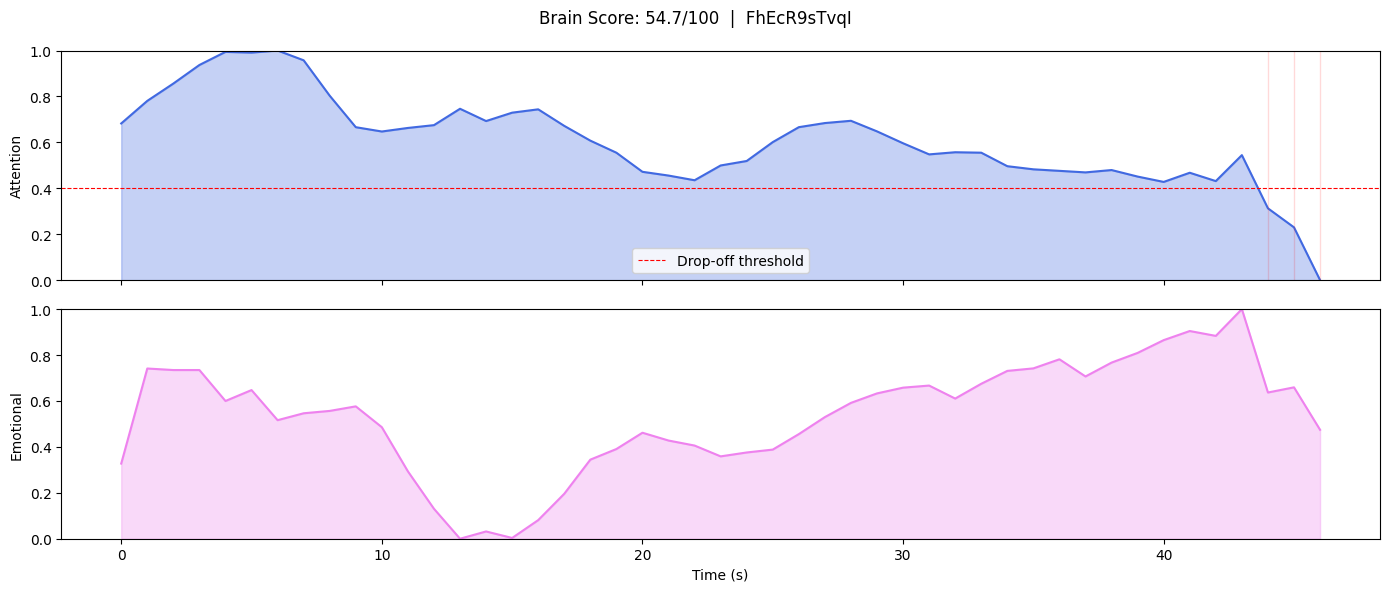

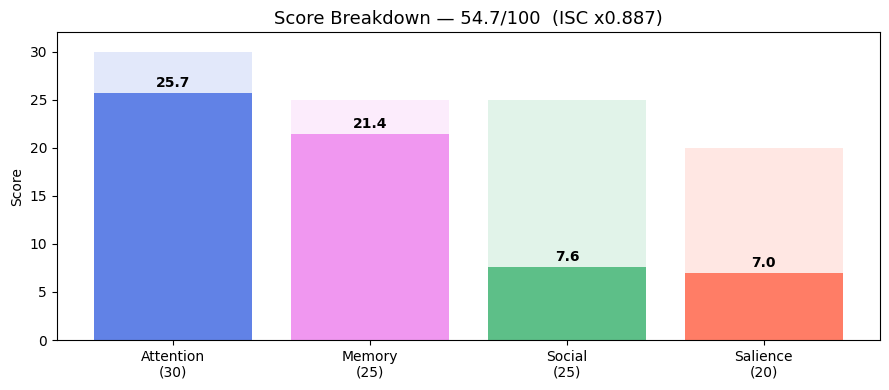

In [73]:
# ── 10. VISUALISE A RESULT ───────────────────────────────────────────────────

# VIDEO_URLS = [

#     "https://youtube.com/shorts/VqBmPmVxwV8?si=6hiaYLdtyEfNRuo5",
#     "https://youtube.com/shorts/IQxea9UB1nQ?si=UT58Un96hwoj0Qan",
#     "https://youtube.com/shorts/JktNgjnAv9s?si=jVBTjOOyRRTcVQjq",
#     "https://youtube.com/shorts/FhEcR9sTvqI?si=pJq_depDmaJgAVXD",
#     "https://youtube.com/shorts/BgqyapYlwy8?si=kbo6FqioKfx02H1De",
# ]



# Set VIDEO_ID to any video_id from the summary above.
print('Visualising a scored video...')
VIDEO_ID = _video_id(VIDEO_URLS[3])

preds_path, segs_path = _preds_paths(VIDEO_ID)
preds_v = np.load(preds_path)
with open(segs_path, 'rb') as f: segs_v = pickle.load(f)

cached = next((x for x in all_results if x['video_id'] == VIDEO_ID), None)
if cached is None or cached.get('dimensions') is None:
    r = compute_brain_score(preds_v, segs_v)
    r['url'] = VIDEO_ID
else:
    r = cached

timeline  = build_engagement_timeline(preds_v, segs_v)
times     = np.array(timeline['times'])
attention = np.array(timeline['attention'])
emotional = np.array(timeline['emotional'])

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f"Brain Score: {r['brain_score']}/100  |  {r['url'][:70]}", fontsize=12)
axes[0].fill_between(times, attention, alpha=0.3, color='royalblue')
axes[0].plot(times, attention, color='royalblue', lw=1.5)
axes[0].axhline(0.4, color='red', ls='--', lw=0.8, label='Drop-off threshold')
axes[0].set_ylabel('Attention'); axes[0].set_ylim(0,1); axes[0].legend()
axes[1].fill_between(times, emotional, alpha=0.3, color='violet')
axes[1].plot(times, emotional, color='violet', lw=1.5)
axes[1].set_ylabel('Emotional'); axes[1].set_xlabel('Time (s)'); axes[1].set_ylim(0,1)
drop = times[attention < 0.4]
if len(drop): [axes[0].axvline(t, color='red', alpha=0.15, lw=1) for t in drop]
plt.tight_layout(); plt.show()

dims   = r['dimensions']
labels = ['Attention\n(30)','Memory\n(25)','Social\n(25)','Salience\n(20)']
scores = [dims['sustained_attention'],dims['emotional_memory'],dims['social_processing'],dims['sensory_salience']]
maxes, colors = [30,25,25,20], ['royalblue','violet','mediumseagreen','tomato']
fig, ax = plt.subplots(figsize=(9,4))
bars = ax.bar(labels, scores, color=colors, alpha=0.8)
ax.bar(labels, maxes, color=colors, alpha=0.15)
for b, s in zip(bars, scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{s:.1f}',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0,32)
ax.set_title(f"Score Breakdown — {r['brain_score']}/100  (ISC x{r['isc_multiplier']})", fontsize=13)
ax.set_ylabel('Score'); plt.tight_layout(); plt.show()